# PyMC-1 : Configuration et Premier Modele

**Navigation** : [Index](../README.md) | [Fin de serie >>](PyMC-2-Gaussian-Mixtures.ipynb)

**Equivalent Infer.NET** : [Infer-1-Setup](../Infer/Infer-1-Setup.ipynb)

**Objectifs** :
- Installer et configurer PyMC dans un notebook Jupyter
- Comprendre le workflow : Modele → Echantillonnage → Posterior
- Implementer le probleme des deux pieces (Two Coins)
- Maitriser les priors conjugues Beta-Bernoulli
- Comparer avec l'approche Infer.NET

## 1. Installation et Import

In [1]:
%pip install pymc arviz matplotlib numpy scipy

Note: you may need to restart the kernel to use updated packages.


In [2]:
try:
    import numpy as np
    NUMPY_AVAILABLE = True
except ImportError:
    NUMPY_AVAILABLE = False

try:
    import matplotlib
    import matplotlib.pyplot as plt
    MATPLOTLIB_AVAILABLE = True
except ImportError:
    MATPLOTLIB_AVAILABLE = False

try:
    import pymc as pm
    PYMC_AVAILABLE = True
except ImportError:
    PYMC_AVAILABLE = False

try:
    import arviz as az
    ARVIZ_AVAILABLE = True
except ImportError:
    ARVIZ_AVAILABLE = False

if NUMPY_AVAILABLE and PYMC_AVAILABLE:
    print(f"PyMC version: {pm.__version__}")
    print(f"ArviZ version: {az.__version__}")
else:
    print("PyMC n'est pas installe. Executez: %pip install pymc arviz matplotlib numpy scipy")

PyMC version: 5.28.5
ArviZ version: 0.23.4


## 2. Programmation Probabiliste avec PyMC

### Infer.NET vs PyMC

| Concept | Infer.NET | PyMC |
|---------|-----------|------|
| Variable | `Variable<T>` | `pm.Distribution` |
| Modele | Classe C# implicite | `pm.Model()` context |
| Inference | `InferenceEngine` (EP/VMP) | `pm.sample()` (NUTS) |
| Resultat | `Gaussian`, `Beta` objects | `InferenceData` (ArviZ) |
| Observation | `.ObservedValue(data)` | `observed=` kwarg |

### Workflow PyMC en 3 etapes

1. **Definir** le modele (distributions, relations, observations)
2. **Echantillonner** le posterior (`pm.sample`)
3. **Analyser** les resultats (ArviZ: traces, summaries, plots)

## 3. Exemple : Probleme des Deux Pieces

Le meme probleme que dans Infer-1-Setup : on lance deux pieces, on observe le nombre de faces. Quelle est la probabilite que les deux pieces soient biaisees ?

In [3]:
# Donnees observees : 10 lancers, 7 faces
n_lancers = 10
n_faces = 7

# Modele PyMC : Beta-Bernoulli conjugue
with pm.Model() as two_coins:
    # Prior : Uniforme (Beta(1,1)) sur la probabilite de face
    theta = pm.Beta('theta', alpha=1, beta=1)
    
    # Vraisemblance : observations binomiales
    faces = pm.Binomial('faces', n=n_lancers, p=theta, observed=n_faces)
    
    # Echantillonnage du posterior
    trace = pm.sample(2000, random_seed=42)

# Le posterior est Beta(alpha + faces, beta + piles) = Beta(8, 4)
print(f"Prior: Beta(1, 1)")
print(f"Posterior analytique: Beta({1 + n_faces}, {1 + n_lancers - n_faces})")
print(f"E[theta] = {(1 + n_faces) / (2 + n_lancers):.3f}")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [theta]


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 21 seconds.


Prior: Beta(1, 1)
Posterior analytique: Beta(8, 4)
E[theta] = 0.667


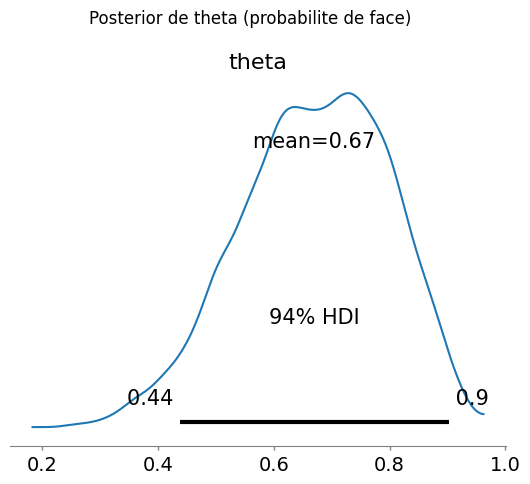

In [4]:
# Visualisation du posterior
az.plot_posterior(trace, var_names=['theta'])
plt.suptitle('Posterior de theta (probabilite de face)', y=1.02)
plt.show()

## 4. Prior Conjugue Beta-Bernoulli

Le couple Beta-Bernoulli est conjugue : le posterior a la meme forme que le prior.

$$\text{Prior: } \theta \sim \text{Beta}(\alpha, \beta)$$
$$\text{Vraisemblance: } x_i \sim \text{Bernoulli}(\theta)$$
$$\text{Posterior: } \theta | x \sim \text{Beta}(\alpha + \sum x_i,\ \beta + n - \sum x_i)$$

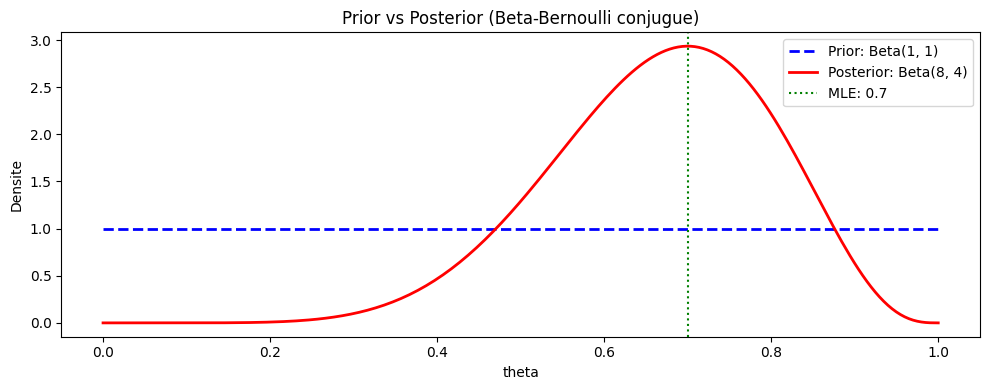

In [5]:
# Comparaison prior vs posterior
from scipy import stats

x = np.linspace(0, 1, 200)
prior = stats.beta(1, 1)
posterior = stats.beta(1 + n_faces, 1 + n_lancers - n_faces)

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.plot(x, prior.pdf(x), 'b--', label='Prior: Beta(1, 1)', linewidth=2)
ax.plot(x, posterior.pdf(x), 'r-', label=f'Posterior: Beta({1+n_faces}, {1+n_lancers-n_faces})', linewidth=2)
ax.axvline(n_faces / n_lancers, color='g', linestyle=':', label=f'MLE: {n_faces/n_lancers:.1f}')
ax.set_xlabel('theta')
ax.set_ylabel('Densite')
ax.legend()
ax.set_title('Prior vs Posterior (Beta-Bernoulli conjugue)')
plt.tight_layout()
plt.show()

## 5. Apprentissage en Ligne

Mise a jour sequentielle du posterior : chaque nouvelle observation met a jour le prior.

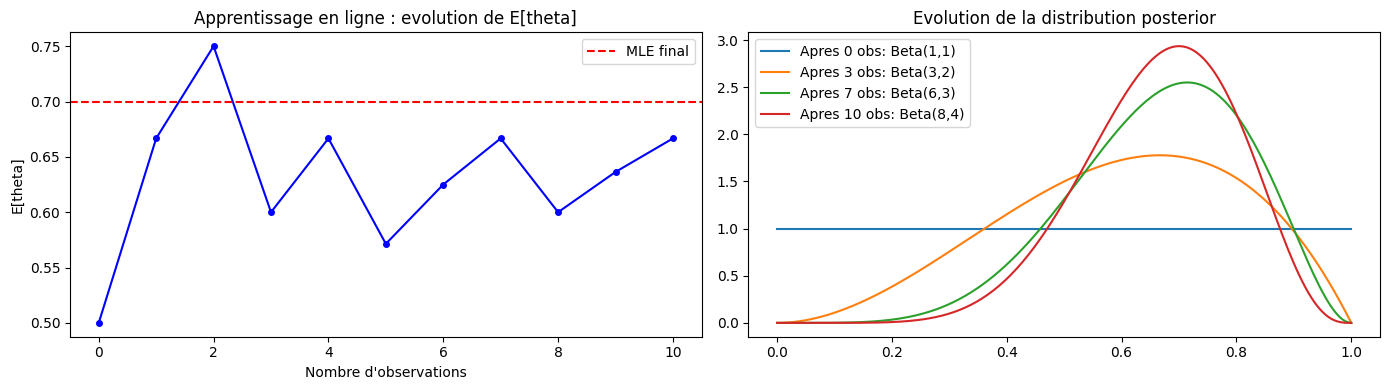

In [6]:
# Apprentissage en ligne : arrivent sequentiellement
observations = [1, 1, 0, 1, 0, 1, 1, 0, 1, 1]  # 1=face, 0=pile

alpha, beta_param = 1, 1  # Prior initial

alphas, betas, means = [alpha], [beta_param], [alpha / (alpha + beta_param)]

for obs in observations:
    if obs == 1:
        alpha += 1
    else:
        beta_param += 1
    alphas.append(alpha)
    betas.append(beta_param)
    means.append(alpha / (alpha + beta_param))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Evolution de la moyenne
axes[0].plot(range(len(means)), means, 'b-o', markersize=4)
axes[0].axhline(sum(observations) / len(observations), color='r', linestyle='--', label='MLE final')
axes[0].set_xlabel('Nombre d\'observations')
axes[0].set_ylabel('E[theta]')
axes[0].set_title('Apprentissage en ligne : evolution de E[theta]')
axes[0].legend()

# Evolution de la distribution
x = np.linspace(0, 1, 200)
for i in [0, 3, 7, 10]:
    d = stats.beta(alphas[i], betas[i])
    axes[1].plot(x, d.pdf(x), label=f'Apres {i} obs: Beta({alphas[i]},{betas[i]})')
axes[1].set_title('Evolution de la distribution posterior')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Comparaison avec Infer.NET

### Code Infer.NET equivalent

```csharp
// Infer.NET (C#)
Variable<double> theta = Variable.Beta(1, 1);
VariableArray<bool> flips = Variable.Observed(observedData, range);
flips[range] = Variable.Bernoulli(theta);

InferenceEngine engine = new InferenceEngine();
engine.Compiler.CompilerChoice = CompilerChoice.Roslyn;
Console.WriteLine(engine.Infer(theta));  // Beta(8, 4)
```

### Differences cles

| Aspect | Infer.NET | PyMC |
|--------|-----------|------|
| Algorithme | Expectation Propagation | NUTS (Hamiltonian Monte Carlo) |
| Resultat | Distribution analytique exacte | Echantillons du posterior |
| Precision | Exact pour conjugues | Monte Carlo (converge) |
| Scalabilite | Message passing (rapide) | MCMC (plus lent mais general) |

## Exercice : Piece Biaisee Inconnue

On a une piece dont on ne connait pas le biais. On effectue 20 lancers et obtient 15 faces.

1. Definir un modele PyMC avec un prior Beta(2, 5) (on soupconne la piece d'etre biaisee vers pile)
2. Calculer le posterior
3. Afficher la distribution posterior
4. Quelle est la probabilite a posteriori que theta > 0.7 ?

In [7]:
# TODO etudiant : implementer le modele pour la piece biaisee
# Indices :
# - Utiliser pm.Model() context
# - Prior: pm.Beta('theta', alpha=2, beta=5)
# - Vraisemblance: pm.Binomial('faces', n=20, p=theta, observed=15)
# - Echantillonner avec pm.sample(2000)
# - Calculer P(theta > 0.7) avec (trace.posterior['theta'] > 0.7).mean()

print("Exercice a completer")

Exercice a completer


---

**Retour au sommaire** : [Index Probas](../README.md)